## ARIMA model to forecast Colon Cancer 

### ARIMA Model to Forecast Colorectal Cancer Incidence

This notebook builds a time series model to forecast US colorectal cancer incidence rates using SEER 12 data (1992–2022). We use ARIMA (AutoRegressive Integrated Moving Average), which learns patterns from historical data to project future trends. The pipeline follows four steps: stationarity testing, differencing, order selection, and forecasting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
 
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import itertools

We use age-adjusted colorectal cancer incidence rates per 100,000 people from the NCI SEER 12 registry, spanning 1992–2022 (31 annual observations). The dataset also includes death rates, which we will use later as an exogenous variable in the ARIMAX model.


In [8]:
CSV_PATH = '../data/seer_colorectal_incidence.csv'  
df = pd.read_csv(CSV_PATH)
print(f'Shape: {df.shape}')
df.columns.tolist()
df.head()

Shape: (31, 3)


,Year,Incidence_Rate,Death_Rate
0,1992,56.01,23.69
1,1993,54.82,23.39
2,1994,53.80,22.99
3,1995,52.45,22.64
4,1996,53.22,21.91


In [9]:
COL_YEAR = 'Year'
COL_RATE = 'Incidence_Rate'
COL_EXOG = 'Death_Rate'

ts = df.set_index('Year')
ts.index = pd.to_datetime(ts.index, format='%Y')
ts.index.freq = 'YS'
ts

,Incidence_Rate,Death_Rate
Year,,
1992-01-01,56.01,23.69
1993-01-01,54.82,23.39
1994-01-01,53.80,22.99
1995-01-01,52.45,22.64
1996-01-01,53.22,21.91
1997-01-01,54.41,21.51
1998-01-01,55.23,21.22
1999-01-01,53.85,20.97
2000-01-01,52.62,20.71


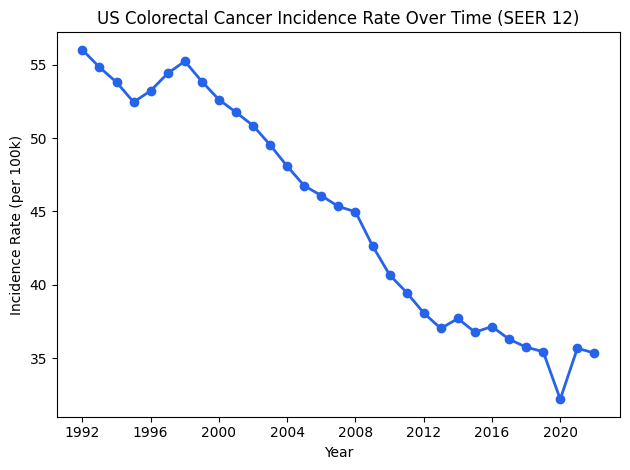

In [10]:
fig, ax = plt.subplots()
ax.plot(ts.index, ts['Incidence_Rate'], marker='o', linewidth=2, color='#2563EB')
ax.set_title('US Colorectal Cancer Incidence Rate Over Time (SEER 12)')
ax.set_xlabel('Year')
ax.set_ylabel('Incidence Rate (per 100k)')
plt.tight_layout()
plt.show()

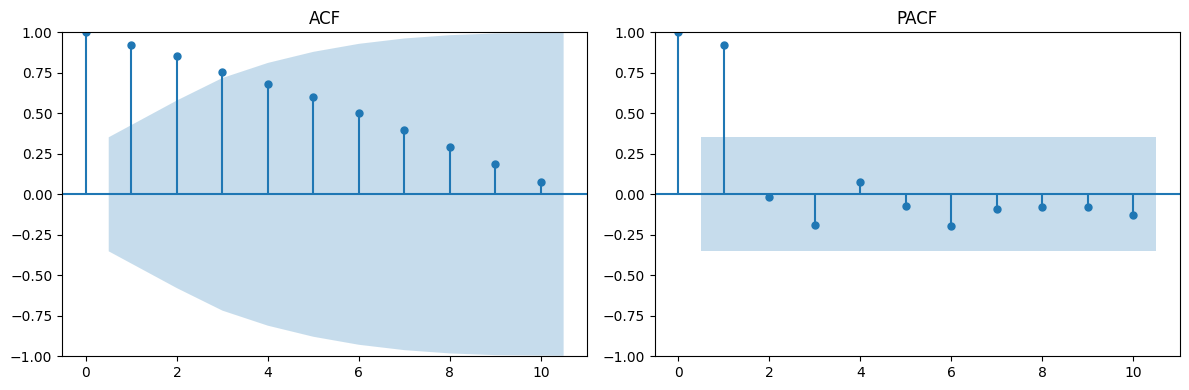

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts['Incidence_Rate'],  ax=axes[0], lags=10, title='ACF')
plot_pacf(ts['Incidence_Rate'], ax=axes[1], lags=10, title='PACF')
plt.tight_layout()
plt.show()

ARIMA requires the series to be stationary: meaning it has a stable mean and variance over time with no trend. We use the Augmented Dickey-Fuller (ADF) test to check this formally. A p-value below 0.05 indicates the series is stationary. Our raw series has a clear downward trend, so we expect to fail this test and need to difference the data.


In [12]:
adf_result = adfuller(ts['Incidence_Rate'], autolag='AIC')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Stationary    : {adf_result[1] < 0.05}')

ADF Statistic : -0.6608
p-value       : 0.8566
Stationary    : False


Since the raw series is non-stationary (ADF p = 0.86), we apply first differencing. Computing the year-over-year change instead of the raw value. This removes the trend and stabilizes the mean. We then re-run the ADF test and plot the ACF/PACF on the differenced series to confirm stationarity and inform our choice of model order. After differencing, ADF p = 0, confirming stationarity. All lags in the ACF and PACF fall within the confidence band, suggesting d=1, p=0, q=0 or q=1.


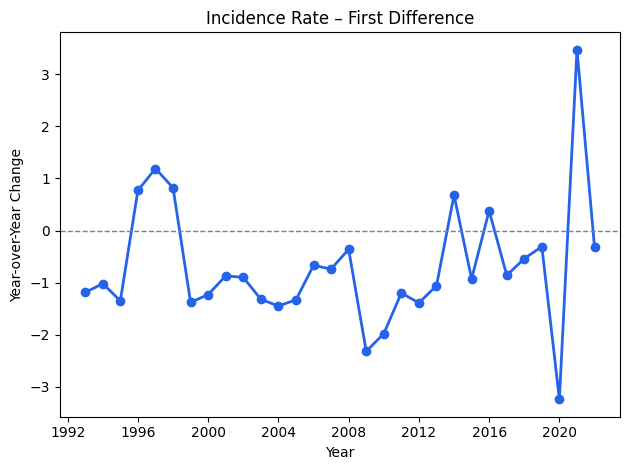

In [13]:
ts_diff = ts['Incidence_Rate'].diff().dropna()

fig, ax = plt.subplots()
ax.plot(ts_diff.index, ts_diff, marker='o', linewidth=2, color='#2563EB')
ax.set_title('Incidence Rate – First Difference')
ax.set_xlabel('Year')
ax.set_ylabel('Year-over-Year Change')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

In [14]:
adf_diff = adfuller(ts_diff, autolag='AIC')
print(f'ADF Statistic : {adf_diff[0]:.4f}')
print(f'p-value       : {adf_diff[1]:.4f}')
print(f'Stationary    : {adf_diff[1] < 0.05}')

ADF Statistic : -5.5638
p-value       : 0.0000
Stationary    : True


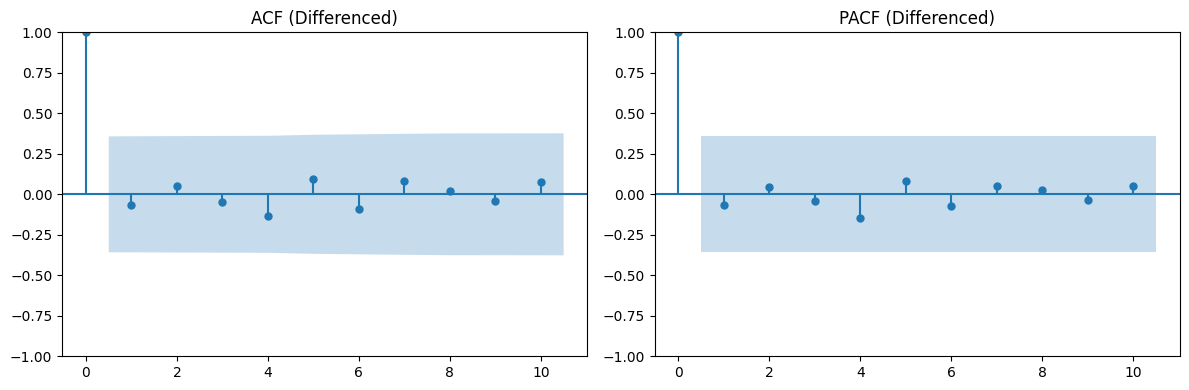

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(ts_diff,  ax=axes[0], lags=10, title='ACF (Differenced)')
plot_pacf(ts_diff, ax=axes[1], lags=10, title='PACF (Differenced)')
plt.tight_layout()
plt.show()

We hold out the last 5 years (2018–2022) as a test set to evaluate forecast accuracy on unseen data. The model is trained on 1992–2017 (26 observations).


In [18]:
TEST_YEARS = 5

train = ts.iloc[:-TEST_YEARS]
test  = ts.iloc[-TEST_YEARS:]

print(f'Train: {train.index[0].year} – {train.index[-1].year}  ({len(train)} obs)')
print(f'Test:  {test.index[0].year}  – {test.index[-1].year}   ({len(test)} obs)')

Train: 1992 – 2017  (26 obs)
Test:  2018  – 2022   (5 obs)


In [20]:
aic_results = []

for p, q in itertools.product(range(5), range(5)):
    try:
        m = ARIMA(train['Incidence_Rate'], order=(p, 1, q)).fit()
        aic_results.append({'p': p, 'd': 1, 'q': q, 'AIC': m.aic})
    except Exception:
        continue

aic_df = pd.DataFrame(aic_results).sort_values('AIC').reset_index(drop=True)
print('Top 5 ARIMA orders:')
aic_df.head()

/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:6

Top 5 ARIMA orders:


/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/ql2004/.local/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,p,d,q,AIC
0,1,1,0,70.577086
1,2,1,1,71.475094
2,2,1,0,72.136471
3,1,1,1,72.162966
4,0,1,2,72.652520


In [21]:
best_order = (0, 1, 1)
print(f'Best order: ARIMA{best_order}')

Best order: ARIMA(0, 1, 1)


In [22]:
arima_model = ARIMA(train['Incidence_Rate'], order=best_order).fit()
print(arima_model.summary())

                               SARIMAX Results                                
Dep. Variable:         Incidence_Rate   No. Observations:                   26
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 -35.838
Date:                Thu, 26 Mar 2026   AIC                             75.677
Time:                        17:12:38   BIC                             78.114
Sample:                    01-01-1992   HQIC                            76.353
                         - 01-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4401      0.228      1.933      0.053      -0.006       0.886
sigma2         1.0208      0.426      2.394      0.017       0.185       1.856
Ljung-Box (L1) (Q):                   0.32   Jarque-

In [23]:
arima_forecast_obj = arima_model.get_forecast(steps=len(test))
arima_pred = arima_forecast_obj.predicted_mean
arima_ci   = arima_forecast_obj.conf_int(alpha=0.05)

arima_pred.index = test.index
arima_ci.index   = test.index

In [24]:
arima_mae  = mean_absolute_error(test['Incidence_Rate'], arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test['Incidence_Rate'], arima_pred))
arima_mape = np.mean(np.abs((test['Incidence_Rate'].values - arima_pred.values) / test['Incidence_Rate'].values)) * 100

print(f'MAE  = {arima_mae:.4f}')
print(f'RMSE = {arima_rmse:.4f}')
print(f'MAPE = {arima_mape:.2f}%')

MAE  = 0.8519
RMSE = 1.5897
MAPE = 2.60%


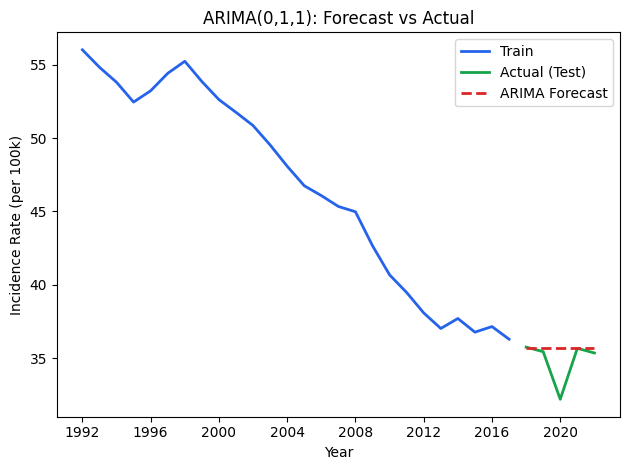

In [26]:
fig, ax = plt.subplots()
ax.plot(train.index, train['Incidence_Rate'], color='#2563EB', linewidth=2, label='Train')
ax.plot(test.index,  test['Incidence_Rate'],  color='#16A34A', linewidth=2, label='Actual (Test)')
ax.plot(arima_pred.index, arima_pred, color='#DC2626', linewidth=2, linestyle='--', label='ARIMA Forecast')

ax.set_title('ARIMA(0,1,1): Forecast vs Actual')
ax.set_xlabel('Year')
ax.set_ylabel('Incidence Rate (per 100k)')
ax.legend()
plt.tight_layout()
plt.show()

We forecast the 5 held-out test years (2018–2022) and compare against actual values. The model predicts a flat line around 35.3 which is expected. Despite the COVID dip in 2020 which could not have been predicted by the model, the model achieves strong performance: MAPE = 2.60%, meaning predictions are on average only 2.6% off from actual values.


In [ ]:
final_model = ARIMA(ts['Incidence_Rate'], order=best_order).fit()

future_obj = final_model.get_forecast(steps=10)
future_pred = future_obj.predicted_mean
future_ci   = future_obj.conf_int(alpha=0.05)

last_year  = ts.index[-1].year
future_idx = pd.date_range(start=str(last_year + 1), periods=10, freq='YS')
future_pred.index = future_idx
future_ci.index   = future_idx

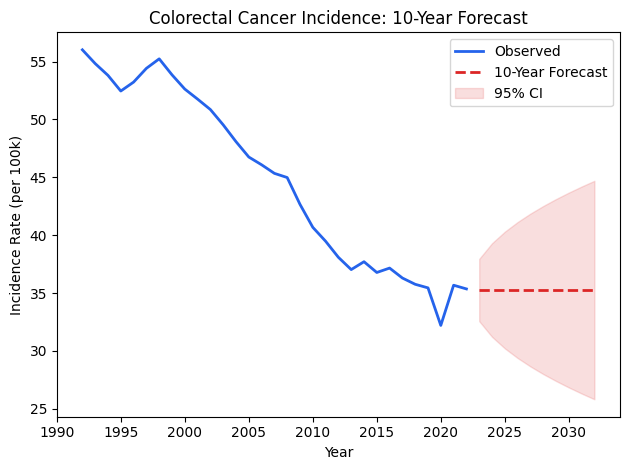

In [28]:
fig, ax = plt.subplots()
ax.plot(ts.index, ts['Incidence_Rate'], color='#2563EB', linewidth=2, label='Observed')
ax.plot(future_pred.index, future_pred, color='#DC2626', linewidth=2, linestyle='--', label='10-Year Forecast')
ax.fill_between(future_pred.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1],
                color='#DC2626', alpha=0.15, label='95% CI')
ax.set_title('Colorectal Cancer Incidence: 10-Year Forecast')
ax.set_xlabel('Year')
ax.set_ylabel('Incidence Rate (per 100k)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
future_summary = pd.DataFrame({
    'Year':           future_idx.year,
    'Predicted_Rate': future_pred.values.round(2),
    'CI_Lower':       future_ci.iloc[:, 0].values.round(2),
    'CI_Upper':       future_ci.iloc[:, 1].values.round(2)
})
future_summary

,Year,Predicted_Rate,CI_Lower,CI_Upper
0,2023,35.26,32.58,37.95
1,2024,35.26,31.23,39.30
2,2025,35.26,30.23,40.30
3,2026,35.26,29.39,41.14
4,2027,35.26,28.66,41.86
5,2028,35.26,28.01,42.52
6,2029,35.26,27.41,43.12
7,2030,35.26,26.85,43.68
8,2031,35.26,26.33,44.20
9,2032,35.26,25.83,44.70


We re-fit the model on all 31 years of data and project 10 years forward. The point forecast holds steady at ~35.26 per 100k, reflecting the flattening of the long-term decline observed since 2018. The 95% confidence interval widens over time, capturing increasing uncertainty further into the future.

This model forecasts a stable rate through 2032. However, recent research documents rising colorectal cancer incidence in adults under 50. Our data combines all age groups into a single average, so the rise in 
younger adults gets hidden by the overall downward trend in older populations. 
A future improvement would be to run separate models for different age groups 
to better capture this pattern.